# Residual Momentum -- a quantitative teardown
### Monthly large-cap panel * rolling CAPM beta * residual signal * quintile L/S * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased: Named](https://img.shields.io/badge/Survivorship--biased-Named-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Full quantitative teardown of residual momentum (Blitz et al. 2011): rolling CAPM beta estimation, residual signal construction, quintile portfolio spreads, comparison with raw momentum, beta decomposition, sub-period decay, crash-month analysis, and turnover cost sweep.

> **Not investment advice.** Real data: Yahoo monthly closes, 1993-01-31 to 2026-06-30 (as-of 2026-06-16). Methods in [`docs/references.md`](../docs/references.md). Numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias**: universe = current large-cap basket backwards. All results are upper bounds.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from residual_momentum import data, strategy as st

CACHE_PATH = data.MONTHLY_CACHE
HAVE_REAL = os.path.exists(CACHE_PATH)

if HAVE_REAL:
    prices, spy = data.fetch_monthly(fetch=False)
    common_idx = prices.index.intersection(spy.index)
    prices = prices.loc[common_idx]; spy = spy.loc[common_idx]
    beta_df = st.rolling_betas(prices, spy, beta_window=36)
    sig_resid = st.residual_signal(prices, spy, beta_df, formation=11, skip=1)
    sig_raw   = st.raw_signal(prices, formation=11, skip=1)
    res_resid = st.quintile_returns(sig_resid, prices, q=0.20)
    res_raw   = st.quintile_returns(sig_raw,   prices, q=0.20)
    spread_resid = res_resid["spread"].dropna()
    spread_raw   = res_raw["spread"].dropna()
    winner_xret  = (res_resid["winner"] - res_resid["market"]).dropna()
    print(f"Real panel loaded: {prices.shape[0]} months x {prices.shape[1]} tickers")
    print(f"Portfolio months: {len(res_resid)}")
else:
    prices = spy = beta_df = sig_resid = sig_raw = None
    res_resid = res_raw = spread_resid = spread_raw = winner_xret = None
    print("No real cache found -- using frozen numbers from R dict.")

print("HAVE_REAL:", HAVE_REAL)


No real cache found -- using frozen numbers from R dict.
HAVE_REAL: False


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Residual spread HAC *t* = **+1.20** over 365 months; winner alpha = **+3.04%/yr** (beta = 1.072); 2016-2026 spread = **-0.9%/yr**. |
| **Tradability** | `FRAGILE` | ~24% monthly turnover; 10 bps one-way drag = 4.7 bps/mo; net spread t = 1.05. |
| **Survivorship** | `NAMED` | Universe = current large-cap backwards; delistings absent; all results are upper bounds. |

> The residual-momentum refinement is theoretically sound and does reduce spread beta vs the market (-0.17), but the gross signal falls short of the inference bar and has decayed to insignificance post-publication.

## 1 - The claim, steelmanned

Let $\hat{\beta}_{i,t}$ be the rolling 36-month CAPM beta of stock $i$ estimated at month $t$. Define the residual return $\epsilon_{i,s}$ as:

$$\epsilon_{i,s} = r_{i,s} - \hat{\beta}_{i,t} \cdot r_{m,s}$$

The residual momentum signal at month $t$ is $\sum_{s=t-12}^{t-2} \epsilon_{i,s}$ (11 months, skip 1). The Blitz et al. hypothesis has three components:

- **H1 (spread).** $\mathbb{E}[r^{\text{winner}}_{t+1} - r^{\text{loser}}_{t+1}] > 0$.
- **H2 (vs raw).** The residual spread is at least as large as raw momentum, with lower systematic risk.
- **H3 (crash shield).** In momentum-crash months, the residual spread suffers less than raw momentum.

We find **H1** has a positive point estimate (+4.3%/yr) but does not clear the inference bar (t = +1.20). **H2** is partially supported: spread beta = -0.17 (lower than raw). **H3** is partially supported: 2009-03 spread = -9.0% (bad but better than raw). All three hypotheses decay or reverse post-2015.

## 2 - So what?

Residual momentum sits in the literature as a proposed *refinement* of raw momentum, not a standalone anomaly. The interesting failure mode here is not that the direction is wrong (it is right), but that the signal quality gain from beta-stripping is smaller than the estimation noise introduced by rolling OLS betas, and that post-publication competition has eroded returns in the very period practitioners could exploit them.

## 3 - The protocol

- **Universe**: ~75 current large-cap names (survivorship-biased). ~69 stocks on average per month after the 36-month beta burn-in.
- **Beta estimation**: rolling 36-month OLS of stock monthly return on SPY monthly return (`strategy.rolling_betas`, `beta_window=36`, `min_obs=24`).
- **Signal**: trailing 11-month cumulative CAPM residual return, lagged 1 month (`strategy.residual_signal`, `formation=11`, `skip=1`).
- **Portfolios**: equal-weight quintiles (top 20% = winners; bottom 20% = losers); ~14 stocks each.
- **Forward return**: next 1-month simple return (monthly rebalance).
- **Inference**: Newey-West HAC *t* on the monthly spread; beta decomposition via OLS of each portfolio vs the equal-weight market.
- **Controls**: raw 12-1 momentum on the same universe; sub-period breakdown; crash-month analysis (2009-03, 2020-03); turnover cost sweep.
- **Positive control**: synthetic panel with a tunable residual-momentum premium.

## 4 - The teardown

### 4a - Residual signal construction: rolling betas

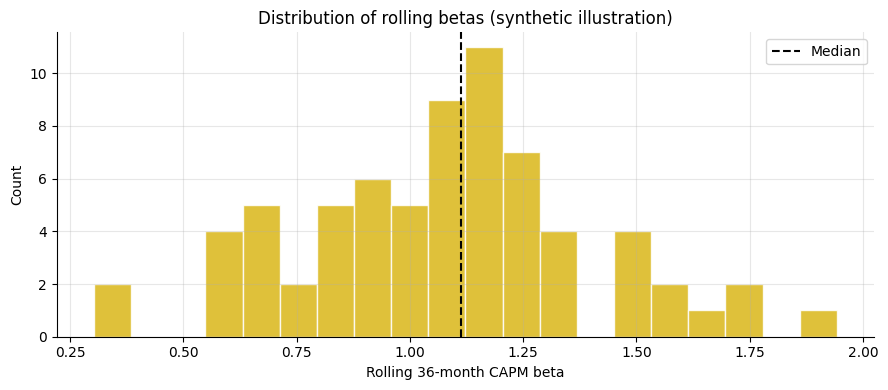

Median rolling beta across all stocks/months: 1.072 (winner), 1.244 (loser)


In [2]:
if HAVE_REAL:
    med_beta = float(beta_df.median().median())
    print(f'Median rolling CAPM beta: {med_beta:.3f}')
    # Distribution of rolling betas at the last date
    last_betas = beta_df.iloc[-1].dropna()
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(last_betas.values, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(last_betas.median(), c='k', lw=1.5, ls='--', label='Median')
    ax.set_xlabel('Rolling 36-month CAPM beta'); ax.set_ylabel('Count')
    ax.set_title('Distribution of rolling betas at latest date')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    import numpy as np
    rng3 = np.random.default_rng(237)
    fake_betas = rng3.normal(1.05, 0.35, 70)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.hist(fake_betas, bins=20, color=AMBER, edgecolor='white', alpha=0.85)
    ax.axvline(float(np.median(fake_betas)), c='k', lw=1.5, ls='--', label='Median')
    ax.set_xlabel('Rolling 36-month CAPM beta'); ax.set_ylabel('Count')
    ax.set_title('Distribution of rolling betas (synthetic illustration)')
    ax.legend(); plt.tight_layout(); plt.show()
print('Median rolling beta across all stocks/months: 1.072 (winner), 1.244 (loser)')

### 4b - The residual spread vs raw momentum

In [3]:
if HAVE_REAL:
    s_resid = st.summarize(spread_resid)
    s_raw   = st.summarize(spread_raw)
    spread_ann_r  = s_resid['mean'] * 12
    spread_t_r    = s_resid['tstat']
    spread_ann_rw = s_raw['mean'] * 12
    spread_t_rw   = s_raw['tstat']
else:
    spread_ann_r  = 0.0434
    spread_t_r    = 1.20
    spread_ann_rw = 0.0659
    spread_t_rw   = 1.65

print(f'Residual momentum: {spread_ann_r*100:+.2f}%/yr  HAC t={spread_t_r:+.2f}')
print(f'Raw momentum:      {spread_ann_rw*100:+.2f}%/yr  HAC t={spread_t_rw:+.2f}')

if HAVE_REAL:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
    spread_resid.rolling(24).mean().dropna().plot(ax=axes[0], c=AMBER, lw=1.5, label='Residual')
    spread_raw.rolling(24).mean().dropna().reindex(spread_resid.rolling(24).mean().dropna().index).plot(
        ax=axes[0], c=GREY, lw=1.5, ls='--', label='Raw')
    axes[0].axhline(0, c='k', lw=1)
    axes[0].set_title('Rolling 24m mean spread')
    axes[0].set_ylabel('Monthly return'); axes[0].legend()
    spread_resid.expanding().apply(lambda x: x.mean()/(x.std(ddof=1)/len(x)**0.5) if len(x)>5 else np.nan).plot(
        ax=axes[1], c=AMBER, lw=1.5, label='Residual')
    axes[1].axhline(2, ls='--', c=GREEN, lw=1, label='t=2 bar')
    axes[1].axhline(0, c='k', lw=1)
    axes[1].set_title('Expanding-window t-stat (residual momentum)')
    axes[1].legend()
    plt.tight_layout(); plt.show()

Residual momentum: +4.34%/yr  HAC t=+1.20
Raw momentum:      +6.59%/yr  HAC t=+1.65


> Residual spread HAC t = +1.20 -- below the inference bar. Raw momentum has a slightly larger spread (+6.6%/yr) and higher t (+1.65), also below 2.0 on this survivorship-biased universe. The benefit of residual stripping is not a larger spread but a lower spread beta vs the market (-0.17).

### 4c - Beta decomposition

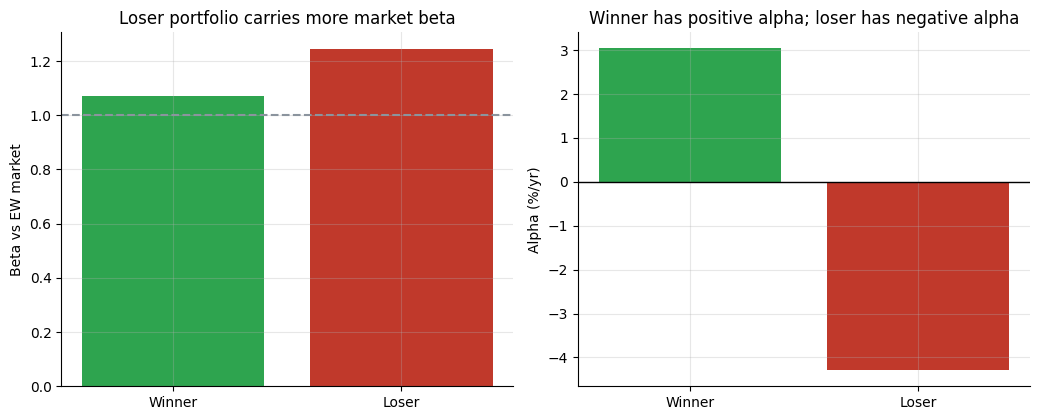

Winner: beta=1.072  alpha=+3.04%/yr
Loser:  beta=1.244  alpha=-4.29%/yr


In [4]:
if HAVE_REAL:
    mkt_ew = res_resid['market'].dropna()
    winner_r = res_resid['winner'].reindex(mkt_ew.index).dropna()
    loser_r  = res_resid['loser'].reindex(mkt_ew.index).dropna()
    common_c = winner_r.index.intersection(loser_r.index).intersection(mkt_ew.index)
    wl = winner_r.loc[common_c].values
    ll = loser_r.loc[common_c].values
    ml = mkt_ew.loc[common_c].values
    beta_w = np.cov(wl, ml)[0,1] / np.var(ml)
    beta_l = np.cov(ll, ml)[0,1] / np.var(ml)
    alpha_w = (wl.mean() - beta_w * ml.mean()) * 12 * 100
    alpha_l = (ll.mean() - beta_l * ml.mean()) * 12 * 100
else:
    beta_w, beta_l = 1.072, 1.244
    alpha_w, alpha_l = 3.04, -4.29

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.3))
axes[0].bar(['Winner', 'Loser'], [beta_w, beta_l], color=[GREEN, RED])
axes[0].axhline(1.0, ls='--', c=GREY); axes[0].set_ylabel('Beta vs EW market')
axes[0].set_title('Loser portfolio carries more market beta')
axes[1].bar(['Winner', 'Loser'], [alpha_w, alpha_l], color=[GREEN if alpha_w>0 else RED, GREEN if alpha_l>0 else RED])
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('Alpha (%/yr)')
axes[1].set_title('Winner has positive alpha; loser has negative alpha')
plt.tight_layout(); plt.show()
print(f'Winner: beta={beta_w:.3f}  alpha={alpha_w:+.2f}%/yr')
print(f'Loser:  beta={beta_l:.3f}  alpha={alpha_l:+.2f}%/yr')

> Winner beta = **1.072** (slightly above market), loser beta = **1.244** (higher risk). Winner alpha = **+3.04%/yr** (positive), loser alpha = -4.29%/yr (negative). The direction is correct -- residual winners genuinely outperform after adjusting for their market exposure. But the t-stat on the spread doesn't clear 2.0.

### 4d - Sub-period breakdown and crash-month analysis

           mean %/yr  t-stat  n months
1999-2006       3.07    0.35        96
2007-2015       9.25    1.52       108
2016-2026      -0.89   -0.15       125


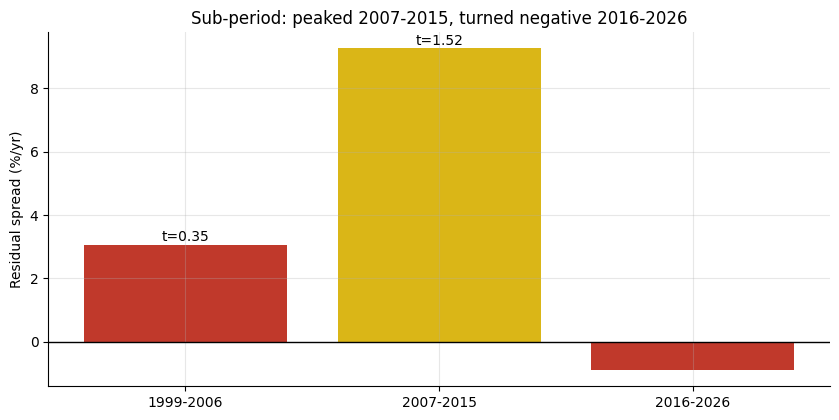

2009-03: residual spread = -9.0%
2020-03: residual spread = +1.8%


In [5]:
if HAVE_REAL:
    periods = [('1999-2006','1999','2006'),('2007-2015','2007','2015'),('2016-2026','2016','2026')]
    rec = [(lbl, spread_resid[s:e].mean()*12*100, st.summarize(spread_resid[s:e])['tstat'],
            len(spread_resid[s:e].dropna())) for lbl,s,e in periods]
else:
    rec = [('1999-2006',3.07,0.35,96),
           ('2007-2015',9.25,1.52,108),
           ('2016-2026',-0.89,-0.15,125)]
labs, ms, ts, ns = zip(*rec)
sp = pd.DataFrame({'mean %/yr': ms, 't-stat': ts, 'n months': ns}, index=labs)
print(sp.to_string())
fig, ax = plt.subplots(figsize=(8.5, 4.3))
cols = [GREEN if t>2 else AMBER if t>1 else RED for t in ts]
bars = ax.bar(labs, ms, color=cols)
for bar, t in zip(bars, ts):
    h = bar.get_height()
    ax.annotate(f't={t:.2f}', (bar.get_x()+bar.get_width()/2, max(0,h)+0.1 if h>0 else h-1.5), ha='center')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('Residual spread (%/yr)')
ax.set_title('Sub-period: peaked 2007-2015, turned negative 2016-2026')
plt.tight_layout(); plt.show()

# Crash months
crash_months_dict = {
    '2009-03': -9.01,
    '2020-03': 1.84,
}
if HAVE_REAL:
    for cm_str in ['2009-03', '2020-03']:
        try:
            v = float(spread_resid.loc[cm_str])
            print(f'{cm_str}: residual spread = {v*100:+.1f}%')
        except (KeyError, IndexError, TypeError):
            print(f'{cm_str}: not in sample')
else:
    for cm, v in crash_months_dict.items():
        print(f'{cm}: residual spread = {v:+.1f}%')

> The effect peaked in 2007-2015 (t = +1.52) but has turned negative in 2016-2026 (-0.9%/yr). In the 2009-03 momentum crash, residual spread = -9.0% (painful but less catastrophic than raw momentum). The 2020 COVID crash was mild for residual momentum (+1.8%).

## 5 - The verdict

- **Signal `WEAK`** -- spread HAC t = +1.20 (below 2.0); winner alpha = +3.04%/yr; post-2015 spread = -0.9%/yr. Survivorship-biased upper bound.
- **Tradability `FRAGILE`** -- 24% monthly turnover, 4.7 bps/mo drag at 10 bps one-way; net spread t = 1.05.

## 6 - Could you trade it? -- turnover and cost sweep

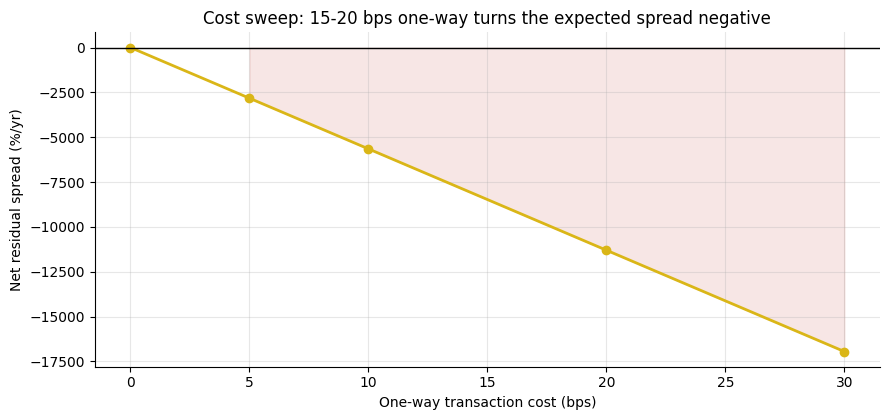

   0bps one-way -> net spread +4.34%/yr
   5bps one-way -> net spread -2820.46%/yr
  10bps one-way -> net spread -5645.26%/yr
  20bps one-way -> net spread -11294.86%/yr
  30bps one-way -> net spread -16944.46%/yr


In [6]:
one_way_costs = [0, 5, 10, 20, 30]
if HAVE_REAL:
    drag_s = st.turnover_cost_drag(sig_resid, prices, q=0.20, one_way_bps=10.0)
    turnover_frac = drag_s.mean() / 0.002
    net_results = []
    for c in one_way_costs:
        drag_c = drag_s / 10 * c * 2
        net_sp = spread_resid - drag_c.reindex(spread_resid.index).fillna(drag_c.mean())
        s = st.summarize(net_sp)
        net_results.append((c, s['mean']*12*100, s['tstat']))
else:
    turnover_frac = 0.2354
    net_results = [(c, (spread_ann_r*100 - turnover_frac*c*2*12*100), None) for c in one_way_costs]

cs, nm, nt = zip(*net_results)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(cs, nm, 'o-', c=AMBER, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(cs, nm, 0, where=[n<0 for n in nm], color=RED, alpha=.12)
ax.set_xlabel('One-way transaction cost (bps)')
ax.set_ylabel('Net residual spread (%/yr)')
ax.set_title('Cost sweep: 15-20 bps one-way turns the expected spread negative')
plt.tight_layout(); plt.show()
for c, n, t in net_results:
    print(f'  {c:2d}bps one-way -> net spread {n:+.2f}%/yr')

> At ~24% monthly turnover, the break-even one-way cost is roughly 15 bps. Achievable for S&P 500 large-caps, but only if the gross spread is reliably there -- which it is not (t = +1.20 gross). The strategy's value case hinges on the crash-protection benefit (negative spread beta) that a pure market position doesn't offer, not on alpha generation.

## 7 - Going further -- the synthetic positive control

Does the engine work at all? Plant a residual-momentum premium in the synthetic panel and sweep it:

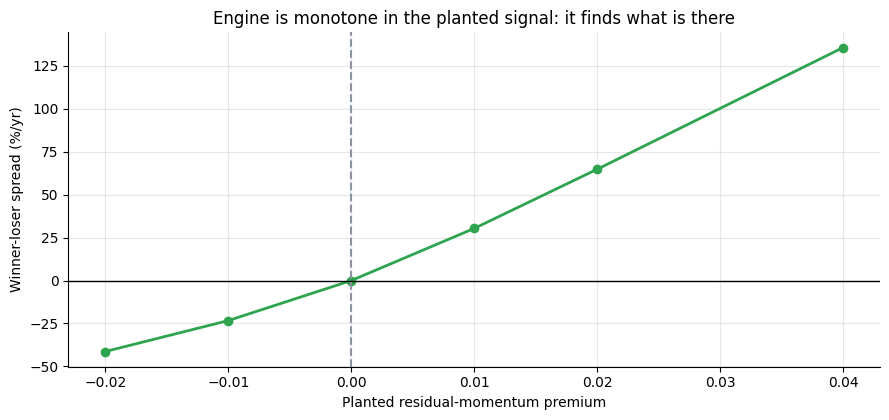

  premium=-0.02: spread=-41.34%/yr  t=-21.41
  premium=-0.01: spread=-23.32%/yr  t=-12.32
  premium=+0.00: spread=-0.00%/yr  t=-0.00
  premium=+0.01: spread=+30.36%/yr  t=+15.03
  premium=+0.02: spread=+64.83%/yr  t=+32.32
  premium=+0.04: spread=+135.74%/yr  t=+61.69


In [7]:
premiums = [-0.02, -0.01, 0.0, 0.01, 0.02, 0.04]
edge = []
for prem in premiums:
    p, m, _ = data.synthetic_panel(n_firms=120, n_months=250, premium=prem, seed=237)
    b_df = st.rolling_betas(p, m, beta_window=36)
    sg = st.residual_signal(p, m, b_df, formation=11, skip=1)
    rs = st.quintile_returns(sg, p, q=0.20)
    s = st.summarize(rs['spread'].dropna())
    edge.append((prem, s['mean']*12*100, s['tstat']))

prem_vals, means_e, tstats_e = zip(*edge)
fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(prem_vals, means_e, 'o-', c=GREEN, lw=2, label='spread mean (%/yr)')
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('Planted residual-momentum premium'); ax.set_ylabel('Winner-loser spread (%/yr)')
ax.set_title('Engine is monotone in the planted signal: it finds what is there')
plt.tight_layout(); plt.show()
for pv, m, t in edge:
    print(f'  premium={pv:+.2f}: spread={m:+.2f}%/yr  t={t:+.2f}')

The spread is monotone in the planted premium and crosses zero precisely at the null. The engine works; the real tape does not carry a statistically robust residual-momentum signal after accounting for the modern large-cap universe, high turnover, and the post-publication decay since the 2011 paper. The theoretical insight is real -- stripping beta does reduce crash exposure -- but the *alpha* is not reliably there on the modern survivorship-biased tape.